# Carga del dataset OASIS

## Carga del dataset utilizando kagglehub

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ninadaithal/imagesoasis")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/imagesoasis


## Carga de las imágenes del dataset clasificandolas por el tipo de demencia

In [16]:
import os
dataset_path = path + '/Data'

# List files in the dataset directory
non_demented_path = os.path.join(dataset_path, 'Non Demented')
moderate_demented_path = os.path.join(dataset_path, 'Moderate Dementia')
mild_demented_path = os.path.join(dataset_path, 'Mild Dementia')
very_mild_demented_path = os.path.join(dataset_path, 'Very mild Dementia')

non_demented_images = [os.path.join(non_demented_path, file) for file in os.listdir(non_demented_path) if file.endswith('.jpg')]
moderate_demented_images = [os.path.join(moderate_demented_path, file) for file in os.listdir(moderate_demented_path) if file.endswith('.jpg')]
mild_demented_images = [os.path.join(mild_demented_path, file) for file in os.listdir(mild_demented_path) if file.endswith('.jpg')]
very_mild_demented_images = [os.path.join(very_mild_demented_path, file) for file in os.listdir(very_mild_demented_path) if file.endswith('.jpg')]

## Dividir cada clase en su conjunto de entrenamiento y test

In [17]:
from sklearn.model_selection import train_test_split
non_demented_train, non_demented_test = train_test_split(non_demented_images, test_size=0.2, random_state=42)
moderate_demented_train, moderate_demented_test = train_test_split(moderate_demented_images, test_size=0.2, random_state=42)
mild_demented_train, mild_demented_test = train_test_split(mild_demented_images, test_size=0.2, random_state=42)
very_mild_demented_train, very_mild_demented_test = train_test_split(very_mild_demented_images, test_size=0.2, random_state=42)


El problema es el desbalance de imágenes que hay en cada clase. Para solucionarlo, se creó un conjunto de prueba y se aumentaron o redujeron imágenes de cada clase para que quedaran equilibradas.

In [18]:
import random
target_samples = 3000

moderate_demented_sample = random.choices(moderate_demented_train, k=target_samples)
mild_demented_sample = random.choices(mild_demented_train, k=target_samples)

very_mild_demented_sample = random.sample(very_mild_demented_train, target_samples)
non_demented_sample = random.sample(non_demented_train, target_samples)

In [19]:
target_samples = 640
mild_demented_test = random.sample(mild_demented_test, target_samples)
non_demented_test = random.sample(non_demented_test, target_samples)
very_mild_demented_test = random.sample(very_mild_demented_test, target_samples)

A continuación redimensionamos las imágenes a (128, 128, 3) y las añadimos a la lista data. Además en la lista result añadimos a que clase pertenece cada imagen:
* 0 si es non_demented
* 1 si es moderate_demented
* 2 si es mild_demented
* 3 si es very_mild_demented

In [20]:
from PIL import Image
import numpy as np
data = []
result = []

for image in non_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(0)

for image in moderate_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(1)

for image in mild_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(2)

for image in very_mild_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(3)

print("Fin de procesado de imágenes de entrenamiento")

Fin de procesado de imágenes de entrenamiento


Dividimos los datos para crear el conjunto de entrenamiento y validación

In [21]:
data = np.array(data)

data.shape

result = np.array(result)
result.shape

X_train, x_val, y_train, y_val = train_test_split(data, result, test_size=0.2, random_state=42)

In [22]:
data_test = []
result_test = []

for image in non_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(0)

for image in moderate_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(1)

for image in mild_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(2)

for image in very_mild_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(3)

print("Fin de procesado de imágenes de test")

data_test = np.array(data_test)
data_test.shape

result_test = np.array(result_test)
result_test.shape

X_test = data_test
y_test = result_test


Fin de procesado de imágenes de test


# PCA

Para poder aplicar los modelos dimensionales es necesario reducir la dimension de nuestro conjunto de datos debido a su alta dimensionalidad. Para el caso del conjunto de entrenamiento, tiene una dimensión de (9600, 49512) cuando se aplana y a la hora de utilizarlo para entrenar a los modelos lineales daba problemas de memoria. Para arreglar este problema se ha estudiado utilizando PCA cuantas características se podría reducir las imágenes. Tras el estudio se decidió reducir las imágenes a 6000 características por lo que el tamaño del conjunto de prueba quedaria en (9600, 6000) pudiendo ser utilizado para entrenar a los modelos lineales.

In [23]:
import matplotlib.pyplot as plt

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV, ShuffleSplit
import joblib

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

K = 6000; pca = PCA(n_components=K); X_train_flat = pca.fit_transform(X_train_flat); X_test_flat = pca.transform(X_test_flat)


# Modelos Lineales

## Linear Discriminant Analysis

LDA asume una matriz de covarianzas común para todas las clases por lo que se tiene en cuenta la correlacion entre las características de las clases. Gracias a esto, LDA es capaz de definir para este conjunto de datos buenas fronteras lineales obteniendo así una precisión en el conjunto de pruebas de un 90,43%

In [24]:
from sklearn.metrics import f1_score
import numpy as np
acc_lds = []
f1_lds = []
for i in range(10):
    ld = LinearDiscriminantAnalysis()
    acc = ld.fit(X_train_flat, y_train).score(X_test_flat, y_test)
    y_pred = ld.predict(X_test_flat)
    f1 = f1_score(y_test, y_pred, average='weighted')
    acc_lds.append(acc)
    f1_lds.append(f1)

print(np.mean(acc_lds))
print(np.mean(f1_lds))

0.9043607532210111
0.9031884708523089


## Quadratic Discriminant Analysis

QDA, a diferencia de LDA asume para cada clase una matriz de covarianzas distintas lo que incrementa la cantidad de parámetros que tiene que aprender el modelo lineal. Debido a esto, se puede aumentar la complejidad del modelo provocando sobreajustes. Tras aplicar QDA, se ha conseguido en el conjunto de pruebas una precisión de 49,10%

In [25]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
acc_qda = []
f1_qda = []
for i in range(10):
    qda = QuadraticDiscriminantAnalysis()
    acc2 = qda.fit(X_train_flat, y_train).score(X_test_flat, y_test)
    y_pred = qda.predict(X_test_flat)
    f1 = f1_score(y_test, y_pred, average='weighted')
    acc_qda.append(acc2)
    f1_qda.append(f1)

print(np.mean(acc_qda))
print(np.mean(f1_qda))

/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:952: RuntimeWarning: overflow encountered in square
  norm2.append(np.sum(X2**2, axis=1))
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:952: RuntimeWarning: overflow encountered in square
  norm2.append(np.sum(X2**2, axis=1))
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:952: RuntimeWarning: overflow encountered in square
  norm2.append(np.sum(X2**2, axis=1))
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:952: RuntimeWarning: overflow encountered in square
  norm2.append(np.sum(X2**2, axis=1))
/usr/local/lib/python3.11/dist-p

0.49108027750247774
0.38238365756344855


## Regresión Logística

La regresión logística es capaz de crear para este conjunto de datos buenas fronteras lineales. Tras aplicar el modelo lineal, se ha obtenido una precisión de 93,80%.

In [26]:
from sklearn.linear_model import LogisticRegression
acc_lr = []
f1_lr = []

for i in range(10):
    lr = LogisticRegression(max_iter=1000, solver='lbfgs')
    acc3 = lr.fit(X_train_flat, y_train).score(X_test_flat, y_test)
    y_pred = lr.predict(X_test_flat)
    f1 = f1_score(y_test, y_pred, average='weighted')
    acc_lr.append(acc3)
    f1_lr.append(f1)
print(np.mean(acc_lr))
print(np.mean(f1_lr))

0.938057482656095
0.9374002268636635


## Naive Bayes

Naive Bayes tampoco necesita calcular matrices de covarianza pero considera que los datos son independientes entre si. El problema de esto es que en las imágenes de radiografías de cerebros, los datos (píxeles) están altamente relacionados por lo que Naive Bayes no dará buenos resultados. Tras aplicar Naive Bayes se consigue una precisión en el conjunto de pruebas de un 38,99%

In [31]:
from sklearn.naive_bayes import GaussianNB
acc_qnb = []
f1_gnb = []

for i in range(10):
    gnb = GaussianNB()
    acc4 = gnb.fit(X_train_flat, y_train).score(X_test_flat, y_test)
    y_pred = gnb.predict(X_test_flat)
    f1 = f1_score(y_test, y_pred, average='weighted')
    acc_qnb.append(acc4)
    f1_gnb.append(f1)
    
print(np.mean(acc_qnb))
print(np.mean(f1_gnb))

0.38999008919722494
0.2845844697137236


# Resultados Finales

Tras calcular la precisión en cada uno de los modelos, se ha elaborado una gráfica para comparar los resultados. La regresión logística ha conseguido los mejores resultados obteniendo una precisión en el conjunto de entrenamiento de un 93,81% mientras que Naive Bayes ha conseguido una precisión del 39%.

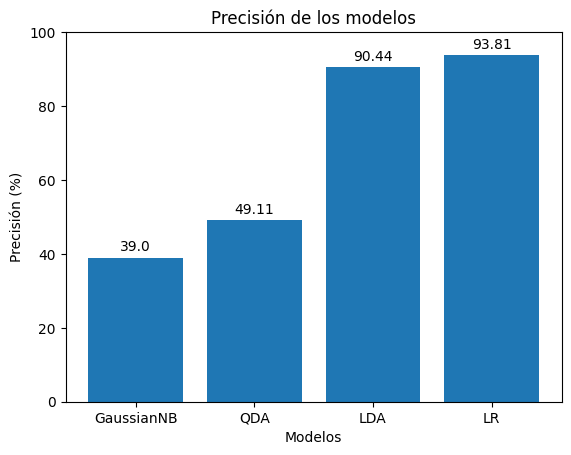

In [33]:
import matplotlib.pyplot as plt

accuracies = [round(np.mean(acc_lds)*100,2), round(np.mean(acc_qda)*100,2), round(np.mean(acc_lr)*100,2), round(np.mean(acc_qnb)*100,2)]
models = ["LDA", "QDA", "LR", "GaussianNB"]

pares = list(zip(models, accuracies))
pares.sort(key=lambda x: x[1])  # ordena por la precisión

models = [p[0] for p in pares]
accuracies = [p[1] for p in pares]

plt.bar(models, accuracies)
plt.ylim(0, 100)
plt.xlabel("Modelos")
plt.ylabel("Precisión (%)")
plt.title("Precisión de los modelos")

# Agregar valores encima de cada barra
for i, val in enumerate(accuracies):
    plt.text(i, val + 1, str(val), ha='center', va='bottom')  # +1 para que no toque la barra

plt.savefig("/kaggle/working/precisiones.png")
plt.show()



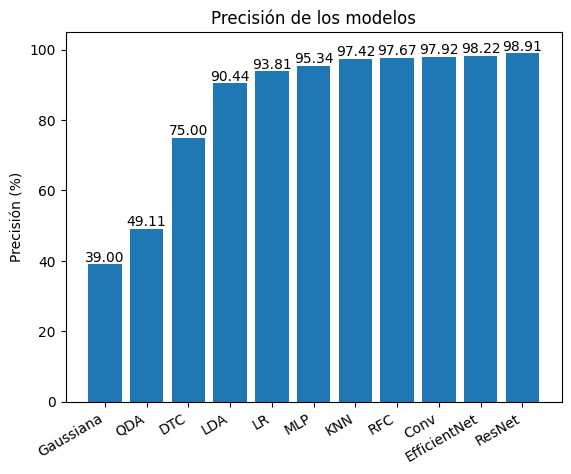

In [1]:
import matplotlib.pyplot as plt

x = ['Gaussiana', 'LDA', 'QDA', 'LR', 'MLP', 'Conv', 'ResNet', 'EfficientNet', 'KNN', 'RFC', 'DTC']
#y = [round(np.mean(acc_qnb)*100,2), round(np.mean(acc_lds)*100,2), round(np.mean(acc_qda)*100,2), 
#     round(np.mean(acc_lr)*100,2), 95.34, 97.92, 98.46, 98.22, 97.42]
y = [39, 90.44, 49.11, 93.81, 95.34, 97.92, 98.91, 98.22, 97.42, 97.67, 75]

indices_orden = sorted(range(len(y)), key=lambda i: y[i])

x_sorted = [x[i] for i in indices_orden]
y_sorted = [y[i] for i in indices_orden]

plt.bar(x_sorted, y_sorted)
plt.ylim(0, 105)
plt.xticks(rotation=30, ha='right')
plt.ylabel("Precisión (%)")
plt.title("Precisión de los modelos")

for i, val in enumerate(y_sorted):
    plt.text(i, val, f"{val:.2f}", ha='center', va='bottom')

plt.show()
